## Setup — Import Libraries and Configure Paths

**What this cell does:**  
We import every Python library that is needed for the entire notebook and set up the folder paths where figures and output files will be saved.

**Why we do it:**  
All code that follows depends on these libraries. Running this cell once at the top means every later cell can use `pd`, `np`, `plt`, etc. without re-importing.

**What to expect:**  
No visible output — the cell simply loads the tools silently.

In [1]:
# Setup — imports, display settings, and output paths
import os
from pathlib import Path
import warnings

os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / "output" / ".matplotlib"))
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

DATA_DIR  = Path("data")
OUTPUT_DIR = Path("output")
FIG_DIR   = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

missing_zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
feature_cols = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
                "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]
target_col = "Outcome"

## Load Both Datasets

**What this cell does:**  
We read the two CSV files from the `data/` folder into Pandas DataFrames: `df_pima` (PIMA Indians Diabetes Database) and `df_frankfurt` (Frankfurt Hospital Diabetes Dataset).

**Why we do it:**  
Loading the data is the first real step of any analysis. Until the data is in memory we cannot inspect, clean, or model it.

**What to expect:**  
No printed output — the DataFrames are stored in memory and will be explored in the cells below.

In [2]:
# Load both CSV datasets into DataFrames
df_pima      = pd.read_csv(DATA_DIR / "pima.csv")
df_frankfurt = pd.read_csv(DATA_DIR / "frankfurt.csv")

## PIMA Dataset — `df.info()`

**What this cell does:**  
Calls `df_pima.info()` to print a concise summary of the PIMA dataset.

**Why we do it:**  
`info()` tells us how many rows and columns the dataset has, the name and data type of each column, and how many non-null (non-missing) values each column contains. This is one of the first checks we do on any new dataset.

**What to expect:**  
A table showing 768 entries, 9 columns, their data types (`int64` / `float64`), and the count of non-null values per column. All 768 values show as non-null here because missing values are currently encoded as zeros — we will deal with that in the next section.

In [3]:
# PIMA dataset: column names, data types, non-null counts
df_pima.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## PIMA Dataset — `df.head()`

**What this cell does:**  
Displays the first five rows of the PIMA dataset.

**Why we do it:**  
Looking at the actual data values helps us understand the scale and format of each column before we start processing. It also lets us spot obvious problems such as impossible zero values (e.g., Insulin = 0).

**What to expect:**  
A table with 5 rows and 9 columns. Notice that some rows already show `0` in columns like Insulin or SkinThickness — those zeros represent missing values that we will handle later.

In [4]:
# PIMA dataset: first 5 rows
df_pima.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Frankfurt Dataset — `df.info()`

**What this cell does:**  
Calls `df_frankfurt.info()` to print the same type of summary for the Frankfurt dataset.

**Why we do it:**  
We need to confirm that the Frankfurt dataset has the same structure (same column names, same data types) as the PIMA dataset before we can merge them later.

**What to expect:**  
2000 entries, 9 columns with the same names as the PIMA dataset. All 2000 entries show as non-null because, again, missing values are encoded as zeros.

In [5]:
# Frankfurt dataset: column names, data types, non-null counts
df_frankfurt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2000 non-null   int64  
 1   Glucose                   2000 non-null   int64  
 2   BloodPressure             2000 non-null   int64  
 3   SkinThickness             2000 non-null   int64  
 4   Insulin                   2000 non-null   int64  
 5   BMI                       2000 non-null   float64
 6   DiabetesPedigreeFunction  2000 non-null   float64
 7   Age                       2000 non-null   int64  
 8   Outcome                   2000 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 140.8 KB


## Frankfurt Dataset — `df.head()`

**What this cell does:**  
Displays the first five rows of the Frankfurt dataset.

**Why we do it:**  
A quick visual check to confirm the data loaded correctly and to compare the value ranges and structure against the PIMA dataset.

**What to expect:**  
A table with 5 rows and 9 columns. The data should look similar to PIMA in structure but different in specific values, reflecting a different patient population.

In [6]:
# Frankfurt dataset: first 5 rows
df_frankfurt.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,1
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,1
3,0,135,68,42,250,42.3,0.365,24,1
4,1,139,62,41,480,40.7,0.536,21,0


## PIMA Dataset — `df.describe()`

**What this cell does:**  
Computes descriptive statistics (count, mean, standard deviation, min, max, and quartiles) for every column in the PIMA dataset.

**Why we do it:**  
Descriptive statistics reveal the distribution and spread of each feature. The most important thing to look for here is the **minimum value** — a `0` in columns like Glucose, BloodPressure, or Insulin is medically impossible and confirms that zeros are being used as a placeholder for missing data.

**What to expect:**  
A statistical summary table with 9 columns. The `min` row for Glucose, BloodPressure, SkinThickness, Insulin, and BMI will show `0`, which signals missing values that we will fix in Cell 2.

In [7]:
# PIMA dataset: count, mean, std, min, quartiles, max for every column
df_pima.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Frankfurt Dataset — `df.describe()`

**What this cell does:**  
Computes the same descriptive statistics for the Frankfurt dataset.

**Why we do it:**  
Comparing the descriptive statistics of both datasets side-by-side (in the cells above and this one) shows whether they have similar distributions, which matters when we merge them. It also reveals the same zero-as-missing problem present in the Frankfurt data.

**What to expect:**  
A statistical summary table similar to the PIMA one. The means and standard deviations should be close between the two datasets, confirming they describe the same kind of population and can be merged.

In [8]:
# Frankfurt dataset: count, mean, std, min, quartiles, max for every column
df_frankfurt.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,3.703500,121.182500,69.145500,20.935000,80.254000,32.193000,0.470930,33.090500,0.342000
std,3.306063,32.068636,19.188315,16.103243,111.180534,8.149901,0.323553,11.786423,0.474498
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,63.500000,0.000000,0.000000,27.375000,0.244000,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,40.000000,32.300000,0.376000,29.000000,0.000000
75%,6.000000,141.000000,80.000000,32.000000,130.000000,36.800000,0.624000,40.000000,1.000000
max,17.000000,199.000000,122.000000,110.000000,744.000000,80.600000,2.420000,81.000000,1.000000


## Cell 2 — Section 3.1: Handling Missing Values

**What this cell does:**  
Some columns contain zeros that are medically impossible — for example, a blood pressure of 0. We treat those zeros as missing values by replacing them with `NaN`. We then visualise the missing data pattern with a heatmap, and finally fill in the missing values using the median of each column.

**Why we do it:**  
Machine learning models cannot use missing values directly. We use the median (instead of the mean) because the median is not affected by extreme values (outliers), making it a more reliable estimate for skewed medical data.

**What to expect:**  
- A table showing how many zeros exist per column before replacement  
- A table showing how many NaN values exist after replacement  
- A side-by-side heatmap for both datasets showing which cells are missing (bright = missing)  
- A confirmation table showing zero missing values after imputation

Zero counts before treating clinical zeros as missing values


,PIMA_zero_count,Frankfurt_zero_count
Glucose,5,13
BloodPressure,35,90
SkinThickness,227,573
Insulin,374,956
BMI,11,28



Missing value counts after replacing zeros with NaN


,PIMA_missing,Frankfurt_missing
Glucose,5,13
BloodPressure,35,90
SkinThickness,227,573
Insulin,374,956
BMI,11,28


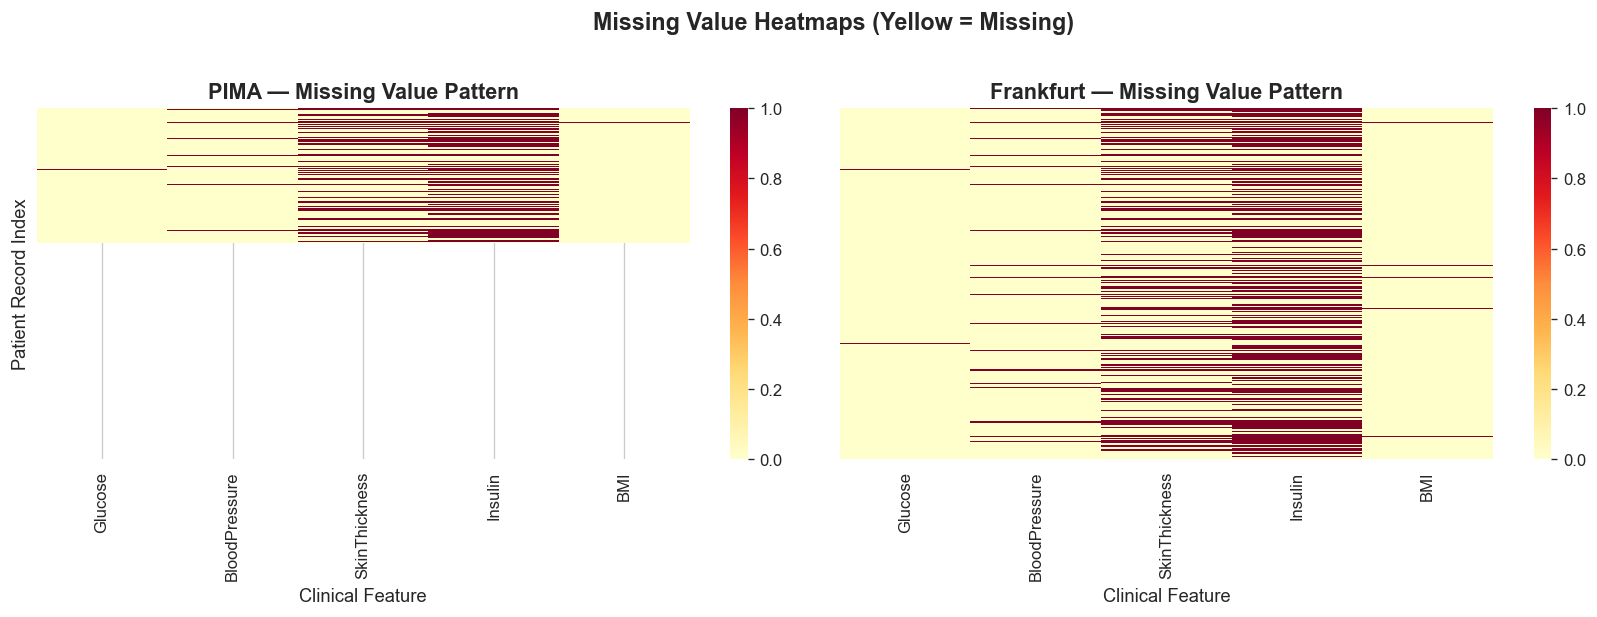


Missing value counts after median imputation


,PIMA_missing_after_imputation,Frankfurt_missing_after_imputation
Glucose,0,0
BloodPressure,0,0
SkinThickness,0,0
Insulin,0,0
BMI,0,0


In [9]:
# Cell 2 — Section 3.1: Handling Missing Values
print("Zero counts before treating clinical zeros as missing values")
zero_counts_before = pd.DataFrame({
    "PIMA_zero_count": (df_pima[missing_zero_cols] == 0).sum(),
    "Frankfurt_zero_count": (df_frankfurt[missing_zero_cols] == 0).sum()
})
display(zero_counts_before)

# Replace physiologically impossible zero values with NaN
df_pima[missing_zero_cols] = df_pima[missing_zero_cols].replace(0, np.nan)
df_frankfurt[missing_zero_cols] = df_frankfurt[missing_zero_cols].replace(0, np.nan)

missing_counts_after = pd.DataFrame({
    "PIMA_missing": df_pima[missing_zero_cols].isna().sum(),
    "Frankfurt_missing": df_frankfurt[missing_zero_cols].isna().sum()
})
print("\nMissing value counts after replacing zeros with NaN")
display(missing_counts_after)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
sns.heatmap(df_pima[missing_zero_cols].isna(), cbar=True, ax=axes[0],
            cmap="YlOrRd", yticklabels=False)
axes[0].set_title("PIMA — Missing Value Pattern", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Clinical Feature", fontsize=11)
axes[0].set_ylabel("Patient Record Index", fontsize=11)
sns.heatmap(df_frankfurt[missing_zero_cols].isna(), cbar=True, ax=axes[1],
            cmap="YlOrRd", yticklabels=False)
axes[1].set_title("Frankfurt — Missing Value Pattern", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Clinical Feature", fontsize=11)
axes[1].set_ylabel("")
plt.suptitle("Missing Value Heatmaps (Yellow = Missing)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_3_1_1_missing_heatmap.png", bbox_inches="tight")
plt.show()

# Median imputation — performed separately per dataset to preserve dataset-specific distributions
for col in missing_zero_cols:
    df_pima[col] = df_pima[col].fillna(df_pima[col].median())
    df_frankfurt[col] = df_frankfurt[col].fillna(df_frankfurt[col].median())

missing_after_imputation = pd.DataFrame({
    "PIMA_missing_after_imputation": df_pima[missing_zero_cols].isna().sum(),
    "Frankfurt_missing_after_imputation": df_frankfurt[missing_zero_cols].isna().sum()
})
print("\nMissing value counts after median imputation")
display(missing_after_imputation)

## Cell 3 — Section 3.2: Data Integration

**What this cell does:**  
We combine (merge) the two datasets into one. Before merging, we add a column called `source` to track which rows came from which dataset. After checking the merged results, we drop the `source` column so it does not interfere with modelling.

**Why we do it:**  
Combining the PIMA dataset (768 patients from the USA) with the Frankfurt dataset (2000 patients from Germany) gives us a larger, more diverse dataset. More data generally leads to better and more generalisable machine learning models.

**What to expect:**  
- The final combined dataset has 2768 rows  
- Source distribution: 768 PIMA rows and 2000 Frankfurt rows  
- Class distribution: majority class is Outcome = 0 (no diabetes)

In [10]:
# Cell 3 — Section 3.2: Data Integration
df_pima["source"] = "PIMA"
df_frankfurt["source"] = "Frankfurt"

df_combined = pd.concat([df_pima, df_frankfurt], axis=0, ignore_index=True)

print(f"Final integrated dataset shape: {df_combined.shape}")
print("\nSource distribution:")
display(df_combined["source"].value_counts().rename_axis("source").reset_index(name="count"))
print("\nClass distribution:")
display(df_combined[target_col].value_counts().sort_index()
        .rename_axis("Outcome").reset_index(name="count"))

# Drop source column before feature engineering and modelling
df_model = df_combined.drop(columns="source").copy()

Final integrated dataset shape: (2768, 10)

Source distribution:


,source,count
0,Frankfurt,2000
1,PIMA,768



Class distribution:


,Outcome,count
0,0,1816
1,1,952


## Cell 4 — Section 3.3 & 3.4: Data Transformation and Standardisation

**What this cell does:**  
This cell has two steps:  
1. **Log transformation** — We apply `np.log1p()` to the `Insulin` and `DiabetesPedigreeFunction` columns to reduce their skewness (i.e., to make the distribution more symmetrical and bell-shaped).  
2. **Standardisation** — We apply `StandardScaler` to all 8 features so that every feature has a mean of 0 and a standard deviation of 1.

**Why we do it:**  
- Skewed data can confuse machine learning models. Log transformation compresses the long tail and makes the distribution more normal.  
- Standardisation is needed because features like Insulin (values 0–800) and DiabetesPedigreeFunction (values 0–2.5) have very different scales. Without scaling, the model would incorrectly treat large-valued features as more important.

**What to expect:**  
- A 2×2 grid of histograms showing Insulin and DiabetesPedigreeFunction before and after log transformation  
- A side-by-side boxplot showing all features before and after standardisation  
- Descriptive statistics after scaling (means near 0, std near 1)

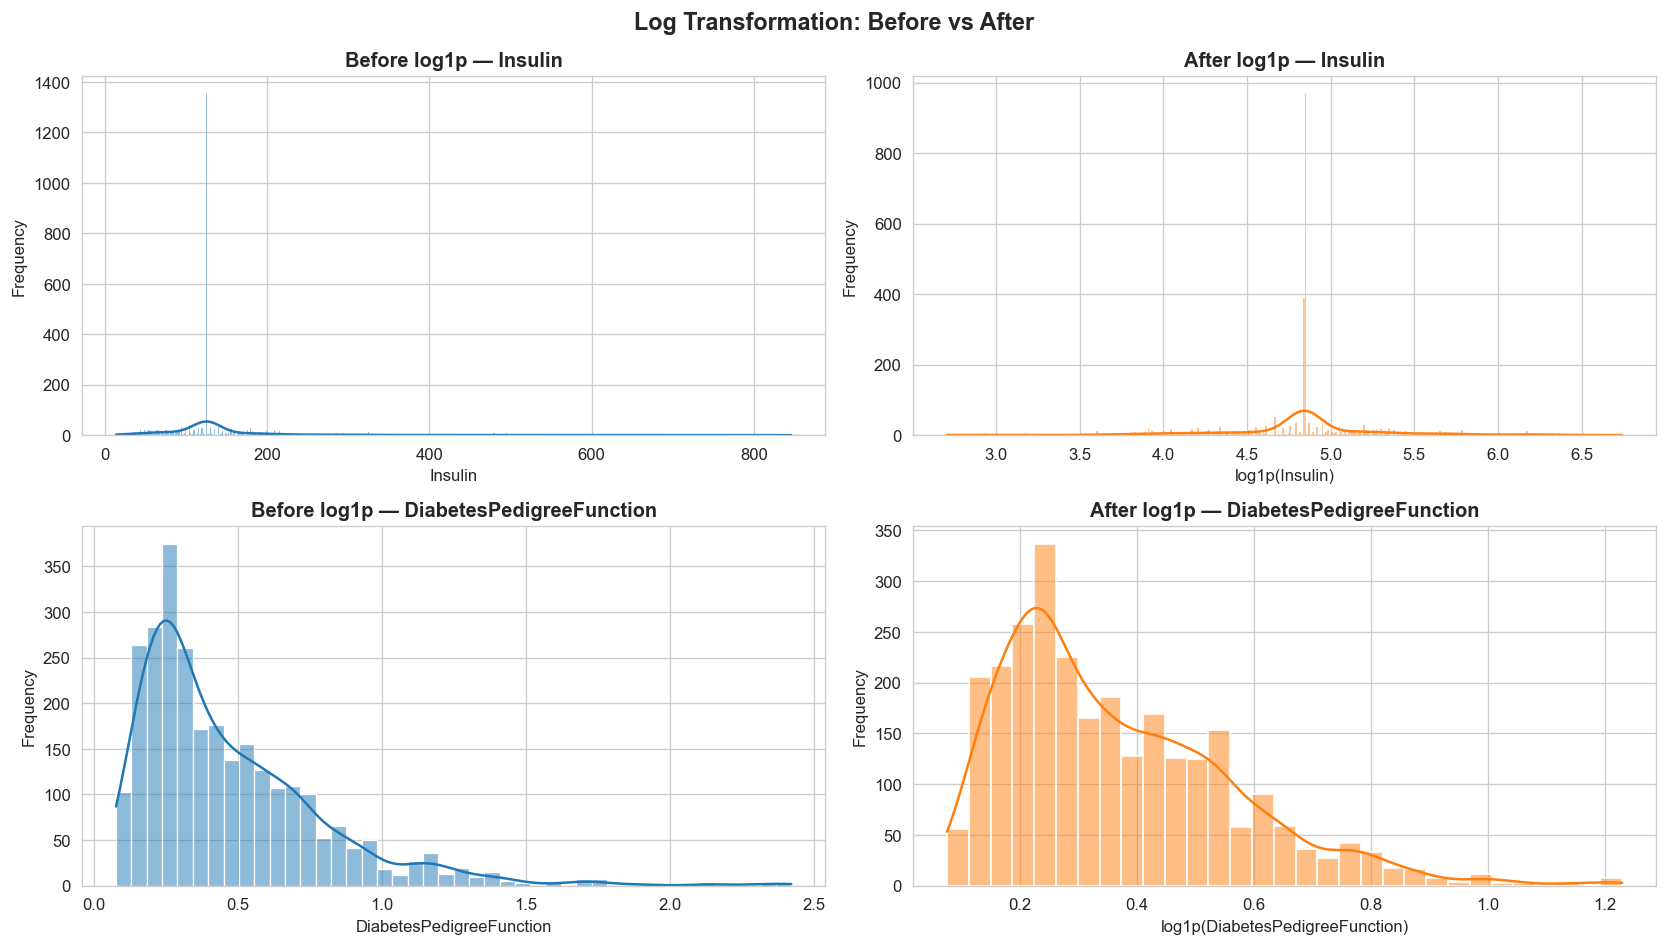

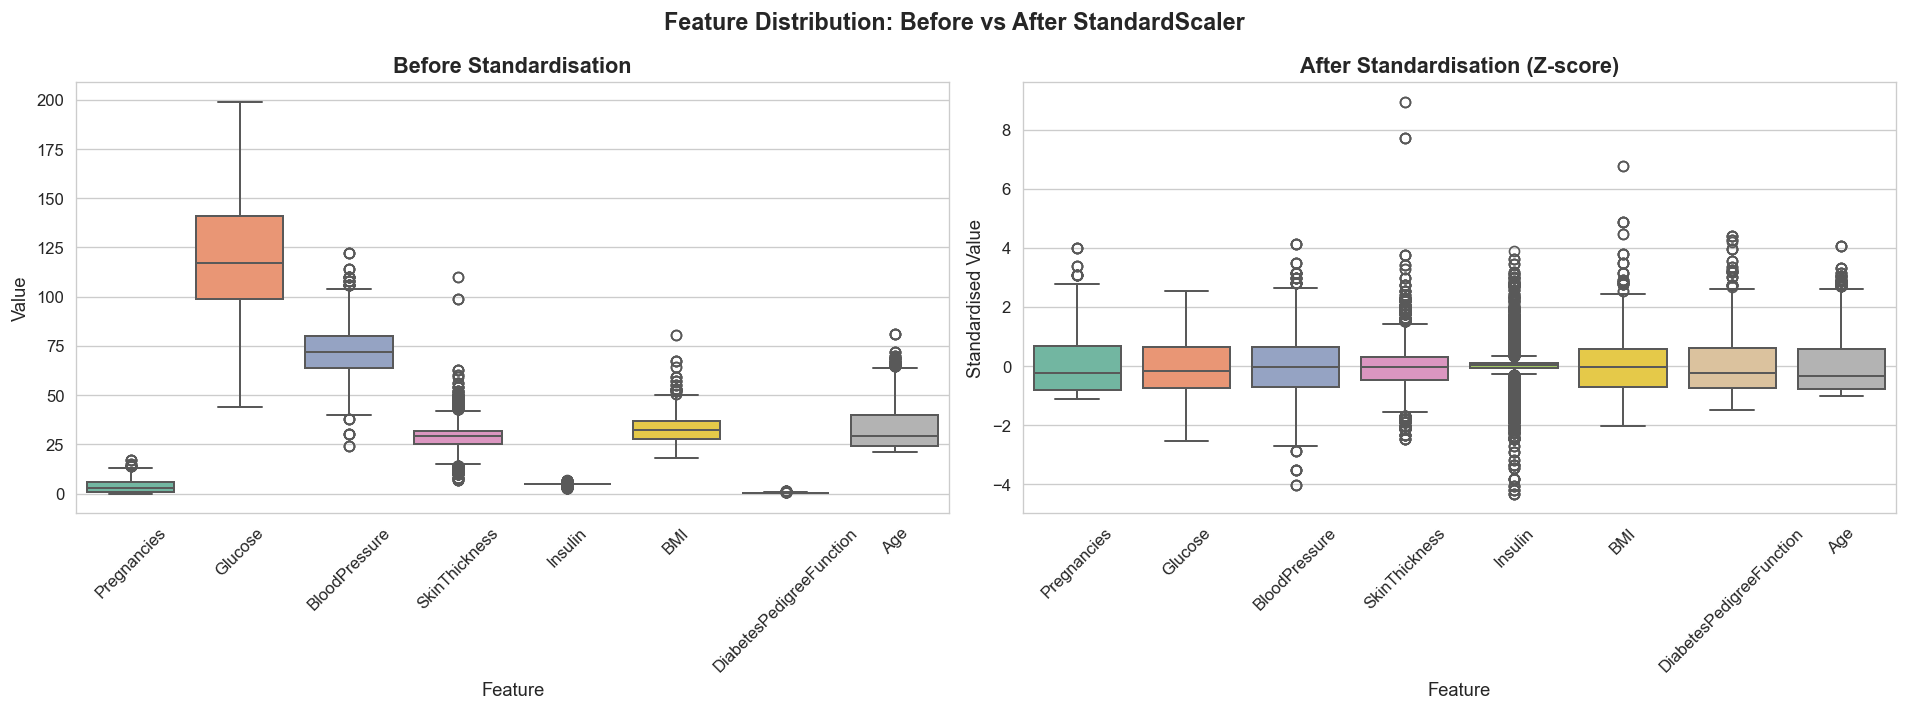

Descriptive statistics after scaling:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,2768.0000,2768.0000,2768.0000,2768.0000,2768.0000,2768.0000,2768.0000,2768.0000
mean,0.0000,-0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000
std,1.0002,1.0002,1.0002,1.0002,1.0002,1.0002,1.0002,1.0002
min,-1.1263,-2.5531,-4.0367,-2.4590,-4.3201,-2.0266,-1.4777,-1.0303
25%,-0.8253,-0.7497,-0.6996,-0.4657,-0.0697,-0.7066,-0.7485,-0.7756
50%,-0.2235,-0.1595,-0.0322,-0.0228,0.0289,-0.0272,-0.2388,-0.3509
75%,0.6792,0.6275,0.6352,0.3094,0.0920,0.5676,0.6086,0.5832
max,3.9893,2.5292,4.1392,8.9467,3.8920,6.7594,4.4003,4.0652


In [11]:
# Cell 4 — Section 3.3 & 3.4: Transformation & Standardisation
X_original = df_model[feature_cols].copy()
y = df_model[target_col].copy()

log_cols = ["Insulin", "DiabetesPedigreeFunction"]
X_transformed = X_original.copy()
before_log = X_transformed[log_cols].copy()
for col in log_cols:
    X_transformed[col] = np.log1p(X_transformed[col])
after_log = X_transformed[log_cols].copy()

# Use a standard two-color palette matching reference style
palette = sns.color_palette("tab10")
color_before = palette[0]   # tab blue
color_after  = palette[1]   # tab orange

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for row, col in enumerate(log_cols):
    sns.histplot(before_log[col], kde=True, ax=axes[row, 0], color=color_before, edgecolor="white")
    axes[row, 0].set_title(f"Before log1p — {col}", fontsize=12, fontweight="bold")
    axes[row, 0].set_xlabel(col, fontsize=10)
    axes[row, 0].set_ylabel("Frequency", fontsize=10)
    sns.histplot(after_log[col], kde=True, ax=axes[row, 1], color=color_after, edgecolor="white")
    axes[row, 1].set_title(f"After log1p — {col}", fontsize=12, fontweight="bold")
    axes[row, 1].set_xlabel(f"log1p({col})", fontsize=10)
    axes[row, 1].set_ylabel("Frequency", fontsize=10)
plt.suptitle("Log Transformation: Before vs After", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_3_3_1_log_transform.png", bbox_inches="tight")
plt.show()

# StandardScaler: transforms each feature to zero mean and unit variance
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X_transformed[feature_cols])
X_scaled = pd.DataFrame(X_scaled_array, columns=feature_cols)

before_melted = X_transformed[feature_cols].melt(var_name="Feature", value_name="Value")
after_melted  = X_scaled.melt(var_name="Feature", value_name="Value")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=before_melted, x="Feature", y="Value", ax=axes[0],
            palette="Set2", linewidth=1.2)
axes[0].set_title("Before Standardisation", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Feature", fontsize=11)
axes[0].set_ylabel("Value", fontsize=11)
axes[0].tick_params(axis="x", rotation=45)
sns.boxplot(data=after_melted, x="Feature", y="Value", ax=axes[1],
            palette="Set2", linewidth=1.2)
axes[1].set_title("After Standardisation (Z-score)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Feature", fontsize=11)
axes[1].set_ylabel("Standardised Value", fontsize=11)
axes[1].tick_params(axis="x", rotation=45)
plt.suptitle("Feature Distribution: Before vs After StandardScaler", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_3_4_1_standardization.png", bbox_inches="tight")
plt.show()

print("Descriptive statistics after scaling:")
display(X_scaled.describe().round(4))

## Cell 5 — Section 3.5: Dimensionality Reduction (PCA)

**What this cell does:**  
We apply Principal Component Analysis (PCA) to the scaled features. PCA finds new axes (called principal components) that capture the most variance in the data. We then plot how much variance each component explains, and draw a cumulative line to see how many components are needed to explain 95% of the total variance.

**Why we do it:**  
PCA helps us understand the complexity of the data. If a small number of components explain most of the variance, it means the features are correlated and contain redundant information. This is useful background knowledge before we move on to feature selection.

**What to expect:**  
- A table showing the explained variance ratio for each of the 8 principal components  
- The number of components needed to explain 95% of the variance  
- A bar-and-line chart: blue bars = individual variance per component, red line = cumulative variance, dashed line at 95%

Explained variance ratio per principal component:


,Component,Explained Variance Ratio,Cumulative Variance
0,PC1,0.2881,0.2881
1,PC2,0.1829,0.4710
2,PC3,0.1360,0.6071
3,PC4,0.1191,0.7262
4,PC5,0.0961,0.8223
5,PC6,0.0686,0.8910
6,PC7,0.0597,0.9507
7,PC8,0.0493,1.0000



Number of components needed for 95% variance: 7


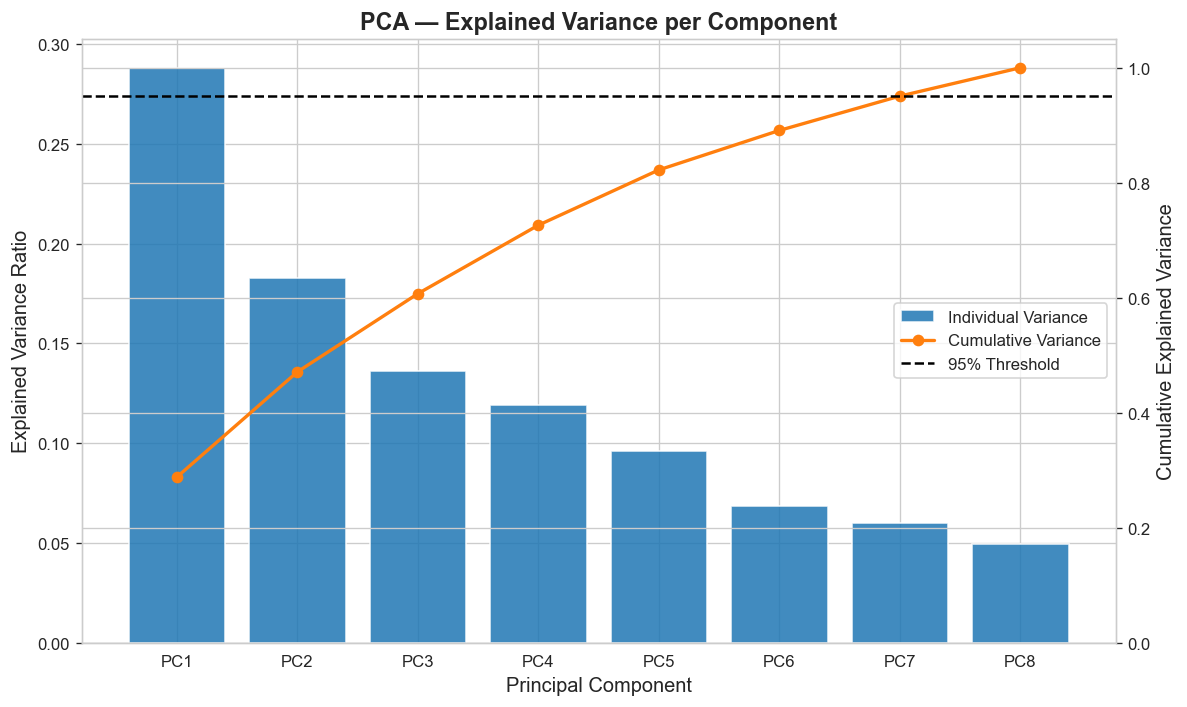

In [12]:
# Cell 5 — Section 3.5: PCA
pca = PCA()
pca.fit(X_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
n_components_95 = int(np.argmax(cumulative_variance >= 0.95) + 1)

variance_df = pd.DataFrame({
    "Component": [f"PC{i}" for i in range(1, len(explained_variance) + 1)],
    "Explained Variance Ratio": explained_variance,
    "Cumulative Variance": cumulative_variance
})
print("Explained variance ratio per principal component:")
display(variance_df.round(4))
print(f"\nNumber of components needed for 95% variance: {n_components_95}")

components = np.arange(1, len(explained_variance) + 1)
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.bar(components, explained_variance, color=sns.color_palette("tab10")[0],
        label="Individual Variance", alpha=0.85)
ax1.set_xlabel("Principal Component", fontsize=12)
ax1.set_ylabel("Explained Variance Ratio", fontsize=12)
ax1.set_xticks(components)
ax1.set_xticklabels([f"PC{i}" for i in components])
ax2 = ax1.twinx()
ax2.plot(components, cumulative_variance, color=sns.color_palette("tab10")[1],
         marker="o", linewidth=2, label="Cumulative Variance")
ax2.axhline(0.95, color="black", linestyle="--", linewidth=1.5, label="95% Threshold")
ax2.set_ylabel("Cumulative Explained Variance", fontsize=12)
ax2.set_ylim(0, 1.05)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right", fontsize=10)
plt.title("PCA — Explained Variance per Component", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_3_5_1_pca_variance.png", bbox_inches="tight")
plt.show()

## Cell 6 — Section 4.0: Feature Selection

**What this cell does:**  
We use two different methods to identify which features are most useful for predicting diabetes:

1. **Mutual Information (MI)** — Measures how much knowing one feature tells us about the target (Outcome). Features with higher MI scores are more informative. We select features that score above the median MI score.

2. **Recursive Feature Elimination (RFE)** — Starts with all features and repeatedly removes the least important one (according to a Logistic Regression model) until only the top 5 remain.

**Why we do it:**  
Not all features contribute equally. Removing irrelevant or redundant features can reduce noise, speed up training, and sometimes improve model accuracy.

**What to expect:**  
- MI scores table and bar chart showing each feature ranked by importance  
- The list of MI-selected features (above median MI score)  
- RFE ranking table showing which features are selected (rank = 1) and which are eliminated  
- RFE bar chart with green bars for selected features and red bars for eliminated ones

Mutual Information Scores (sorted descending):


,Feature,MI Score
0,DiabetesPedigreeFunction,0.3510
1,BMI,0.1914
2,Glucose,0.1831
3,Insulin,0.1342
4,Age,0.0851
5,SkinThickness,0.0430
6,BloodPressure,0.0317
7,Pregnancies,0.0291



Median MI score threshold: 0.1096
MI-selected features: ['DiabetesPedigreeFunction', 'BMI', 'Glucose', 'Insulin']


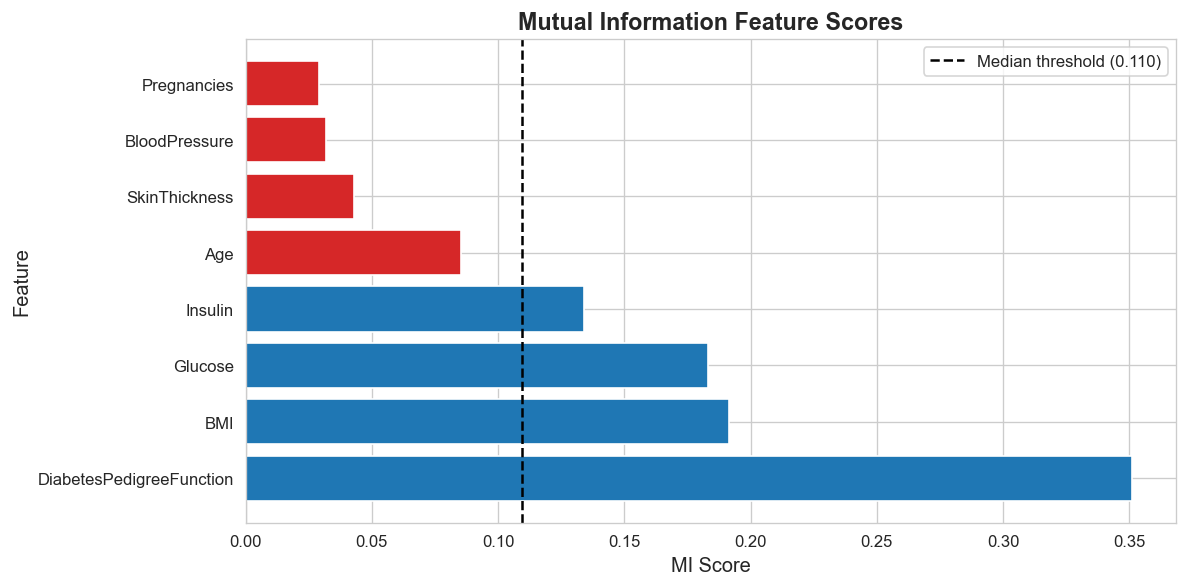


RFE Support and Ranking:


,Feature,Selected,Ranking
0,Age,True,1
1,BMI,True,1
2,DiabetesPedigreeFunction,True,1
3,Glucose,True,1
4,Pregnancies,True,1
5,Insulin,False,2
6,BloodPressure,False,3
7,SkinThickness,False,4



RFE-selected features: ['Age', 'BMI', 'DiabetesPedigreeFunction', 'Glucose', 'Pregnancies']


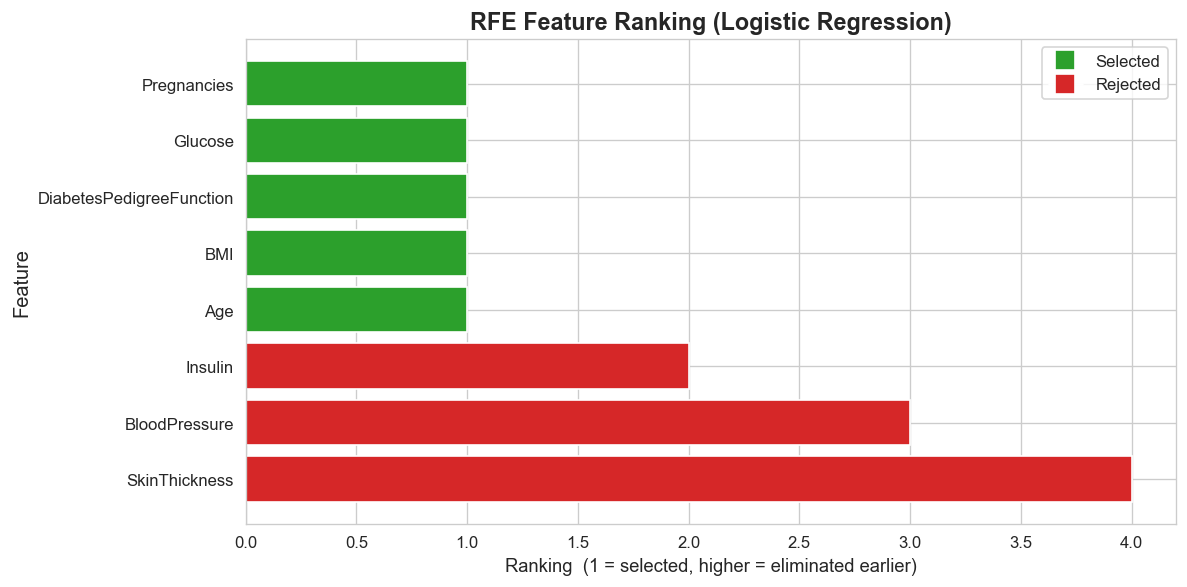

In [13]:
# Cell 6 — Section 4.0: Feature Selection

# ── Mutual Information ────────────────────────────────────────────────────────
mi_scores = mutual_info_classif(X_scaled, y, random_state=42)
mi_df = (pd.DataFrame({"Feature": feature_cols, "MI Score": mi_scores})
         .sort_values("MI Score", ascending=False)
         .reset_index(drop=True))
print("Mutual Information Scores (sorted descending):")
display(mi_df.round(4))

mi_threshold = mi_df["MI Score"].median()
mi_selected_features = mi_df.loc[mi_df["MI Score"] > mi_threshold, "Feature"].tolist()
print(f"\nMedian MI score threshold: {mi_threshold:.4f}")
print("MI-selected features:", mi_selected_features)

fig, ax = plt.subplots(figsize=(10, 5))
colors_mi = [sns.color_palette("tab10")[0] if f in mi_selected_features
             else sns.color_palette("tab10")[3] for f in mi_df["Feature"]]
ax.barh(mi_df["Feature"], mi_df["MI Score"], color=colors_mi, edgecolor="white")
ax.axvline(mi_threshold, color="black", linestyle="--", linewidth=1.5,
           label=f"Median threshold ({mi_threshold:.3f})")
ax.set_title("Mutual Information Feature Scores", fontsize=14, fontweight="bold")
ax.set_xlabel("MI Score", fontsize=12)
ax.set_ylabel("Feature", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_4_2_1_mi_barplot.png", bbox_inches="tight")
plt.show()

# ── RFE ──────────────────────────────────────────────────────────────────────
rfe_estimator = LogisticRegression(max_iter=1000, random_state=42)
rfe = RFE(estimator=rfe_estimator, n_features_to_select=5)
rfe.fit(X_scaled, y)

rfe_df = (pd.DataFrame({
    "Feature": feature_cols,
    "Selected": rfe.support_,
    "Ranking": rfe.ranking_
}).sort_values(["Ranking", "Feature"]).reset_index(drop=True))
print("\nRFE Support and Ranking:")
display(rfe_df)

rfe_selected_features = rfe_df.loc[rfe_df["Selected"], "Feature"].tolist()
print("\nRFE-selected features:", rfe_selected_features)

rfe_plot_df = rfe_df.sort_values("Ranking", ascending=False)
bar_colors = rfe_plot_df["Selected"].map({True: "#2ca02c", False: "#d62728"})
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(rfe_plot_df["Feature"], rfe_plot_df["Ranking"],
        color=bar_colors, edgecolor="white")
ax.set_title("RFE Feature Ranking (Logistic Regression)", fontsize=14, fontweight="bold")
ax.set_xlabel("Ranking  (1 = selected, higher = eliminated earlier)", fontsize=11)
ax.set_ylabel("Feature", fontsize=12)
selected_patch = plt.Line2D([0], [0], marker="s", color="w",
                             markerfacecolor="#2ca02c", markersize=12, label="Selected")
rejected_patch = plt.Line2D([0], [0], marker="s", color="w",
                             markerfacecolor="#d62728", markersize=12, label="Rejected")
ax.legend(handles=[selected_patch, rejected_patch], fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_4_3_1_rfe_ranking.png", bbox_inches="tight")
plt.show()

## Cell 7 — Section 5.0: Model Performance and Output

**What this cell does:**  
We evaluate a Logistic Regression model under three different feature sets:  
1. **All features** (baseline — using all 8 features)  
2. **MI-selected features** (only features chosen by Mutual Information)  
3. **RFE-selected features** (only the 5 features chosen by RFE)

For each scenario we use 5-fold stratified cross-validation and measure four metrics: Accuracy, Precision, Recall, and F1 score. Finally, we save the preprocessed scaled dataset to a CSV file.

**Why we do it:**  
Comparing performance across feature sets shows whether feature selection improves the model or not. Cross-validation gives a more reliable estimate of model performance than a single train/test split.

**What to expect:**  
- A summary table of all three scenarios with their four metric scores  
- A grouped bar chart comparing all scenarios side by side  
- Confirmation that the preprocessed dataset has been saved

Model Performance — 5-Fold Stratified Cross-Validation


,Scenario,Accuracy,Precision,Recall,F1,Features Used
0,All Features (Baseline),0.7673,0.7059,0.5557,0.6216,"Pregnancies, Glucose, BloodPressure, SkinThick..."
1,MI-Selected Features,0.7706,0.7222,0.5410,0.6180,"DiabetesPedigreeFunction, BMI, Glucose, Insulin"
2,RFE-Selected Features,0.7713,0.7163,0.5557,0.6257,"Age, BMI, DiabetesPedigreeFunction, Glucose, P..."


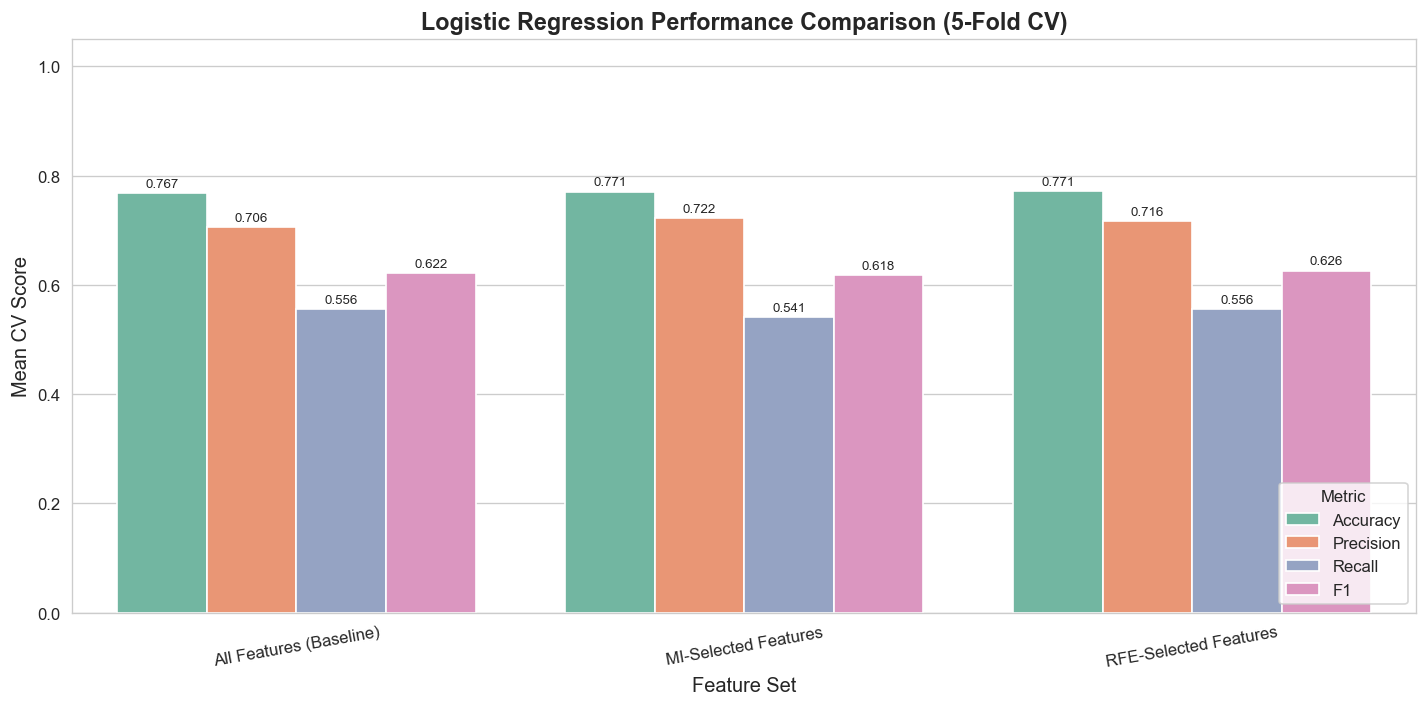


Saved preprocessed dataset to: output/preprocessed_dataset.csv
Saved figures to: output/figures


In [14]:
# Cell 7 — Section 5.0: Model Performance & Save Output
model = LogisticRegression(max_iter=1000, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorers = {
    "Accuracy":  make_scorer(accuracy_score),
    "Precision": make_scorer(precision_score, zero_division=0),
    "Recall":    make_scorer(recall_score,    zero_division=0),
    "F1":        make_scorer(f1_score,        zero_division=0),
}

def evaluate_feature_set(name, selected_features):
    row = {"Scenario": name, "Features Used": ", ".join(selected_features)}
    for metric, scorer in scorers.items():
        scores = cross_val_score(model, X_scaled[selected_features], y,
                                 cv=cv, scoring=scorer)
        row[metric] = round(scores.mean(), 4)
    return row

performance_rows = [
    evaluate_feature_set("All Features (Baseline)", feature_cols),
    evaluate_feature_set("MI-Selected Features",    mi_selected_features),
    evaluate_feature_set("RFE-Selected Features",   rfe_selected_features),
]
performance_df = pd.DataFrame(performance_rows)
print("Model Performance — 5-Fold Stratified Cross-Validation")
display(performance_df[["Scenario", "Accuracy", "Precision", "Recall", "F1", "Features Used"]])

# Grouped bar chart
plot_df = performance_df.melt(
    id_vars=["Scenario", "Features Used"],
    value_vars=["Accuracy", "Precision", "Recall", "F1"],
    var_name="Metric", value_name="Score"
)
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=plot_df, x="Scenario", y="Score", hue="Metric",
            ax=ax, palette="Set2", edgecolor="white")
ax.set_ylim(0, 1.05)
ax.set_title("Logistic Regression Performance Comparison (5-Fold CV)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Feature Set", fontsize=12)
ax.set_ylabel("Mean CV Score", fontsize=12)
ax.tick_params(axis="x", rotation=10)
ax.legend(title="Metric", fontsize=10, title_fontsize=10, loc="lower right")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8, padding=2)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_5_1_performance_comparison.png", bbox_inches="tight")
plt.show()

# Save preprocessed scaled data
preprocessed_output = X_scaled.copy()
preprocessed_output[target_col] = y.reset_index(drop=True)
preprocessed_output.to_csv(OUTPUT_DIR / "preprocessed_dataset.csv", index=False)

print(f"\nSaved preprocessed dataset to: {OUTPUT_DIR / 'preprocessed_dataset.csv'}")
print(f"Saved figures to: {FIG_DIR}")